# 05 · Modelling — XGBoost Nutri-Score Classifier

Predict a product's Nutri-Score grade (A–E) from its nutrition facts, and find
out which nutrients drive the grade.

- **Input:**  `data/products_features.csv`  (from notebook 02)
- **Outputs:** evaluation charts + CSVs that feed the *Model Results* dashboard

We train only on `is_trainable` rows (full nutrition + a known grade) and keep
missing nutrient values as `NaN` — XGBoost handles them natively.

## 1. Setup & load the trainable data

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
df = pd.read_csv(DATA_DIR / "products_features.csv", dtype={"code": "string"})

FEATURES = [
    "energy_kcal_100g", "sugars_100g", "fat_100g", "saturated_fat_100g",
    "salt_100g", "proteins_100g", "fiber_100g",
    "nova_group", "additives_n",
    "sugar_to_energy", "protein_to_energy", "good_minus_bad",
    "is_high_sugar", "is_high_salt", "is_high_sat_fat", "is_ultra_processed",
]
LABELS = ["A", "B", "C", "D", "E"]

model_df = df[df["is_trainable"]].copy()
print(f"Trainable rows: {len(model_df):,}")
print(model_df["grade_encoded"].value_counts().sort_index()
      .rename(index={i: l for i, l in enumerate(LABELS)}).to_string())

Trainable rows: 23,194
grade_encoded
A    3478
B    2681
C    5353
D    5907
E    5775


## 2. Build X / y and split (stratified)

`X` is the features, `y` the encoded grade. Features are cast to float so the
pandas nullable types become plain `NaN` that XGBoost reads natively. The split
is **stratified** so every grade keeps its proportion in train and test.

In [2]:
X = model_df[FEATURES].astype(float)     # keeps NaN, drops pandas nullable dtype
y = model_df["grade_encoded"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")

Train: 18,555   Test: 4,639


## 3. Train the XGBoost classifier

A multi-class classifier (5 grades). The parameters are sensible defaults — depth
and tree count kept moderate to avoid overfitting. XGBoost routes missing values
down a learned branch, so no imputation is needed.

In [3]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 4. Evaluate — accuracy & per-class metrics

In [4]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {acc:.3f}\n")
print("Per-class metrics (precision / recall / f1):")
print(classification_report(y_test, y_pred, target_names=LABELS))

Overall accuracy: 0.856

Per-class metrics (precision / recall / f1):
              precision    recall  f1-score   support

           A       0.83      0.87      0.85       696
           B       0.76      0.68      0.72       536
           C       0.82      0.85      0.83      1071
           D       0.87      0.88      0.88      1181
           E       0.93      0.91      0.92      1155

    accuracy                           0.86      4639
   macro avg       0.84      0.84      0.84      4639
weighted avg       0.86      0.86      0.86      4639



## 5. Confusion matrix

Where the model gets confused. Grades sit on a continuum, so most errors should
be **adjacent** (C↔D, A↔B) rather than wild — that's expected, not a failure.

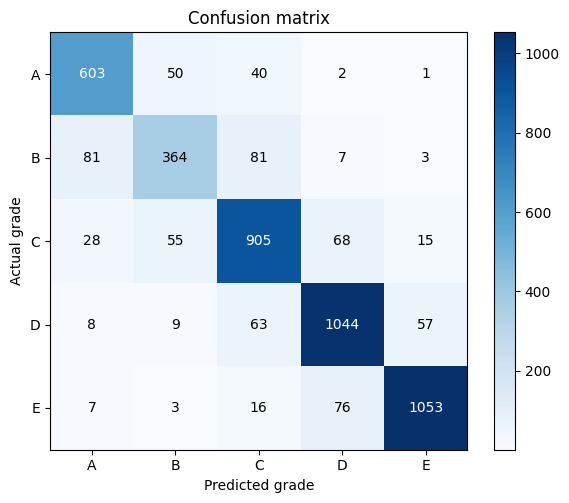

Saved model_confusion_matrix.csv


In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(5)); ax.set_xticklabels(LABELS)
ax.set_yticks(range(5)); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted grade"); ax.set_ylabel("Actual grade")
ax.set_title("Confusion matrix")
for i in range(5):
    for j in range(5):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

# save in long form for Tableau (actual, predicted, count)
cm_long = (pd.DataFrame(cm, index=LABELS, columns=LABELS)
           .reset_index().melt(id_vars="index", var_name="predicted", value_name="count")
           .rename(columns={"index": "actual"}))
cm_long.to_csv(DATA_DIR / "model_confusion_matrix.csv", index=False)
print("Saved model_confusion_matrix.csv")

## 6. Feature importance — which nutrients drive the grade?

This is the real insight: the model tells you what matters most for the Nutri-Score.
Expect sugar, saturated fat and salt to push grades down, protein/fiber up.

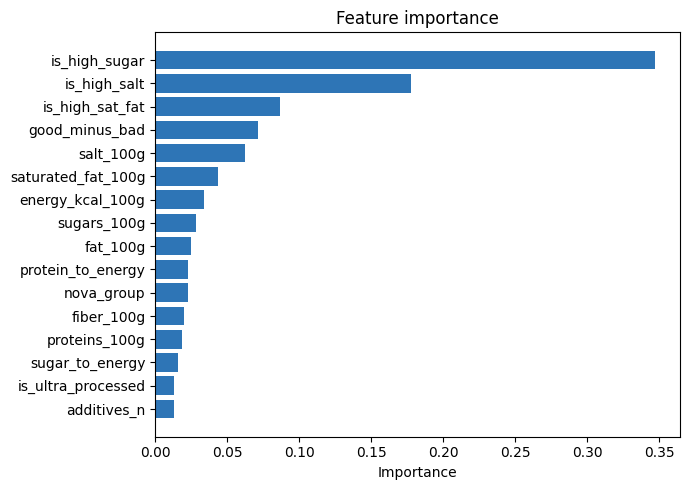

Saved model_feature_importance.csv


,feature,importance
0,is_high_sugar,0.346999
1,is_high_salt,0.177218
2,is_high_sat_fat,0.086442
3,good_minus_bad,0.071041
4,salt_100g,0.062346
5,saturated_fat_100g,0.043673
6,energy_kcal_100g,0.033616
7,sugars_100g,0.027925
8,fat_100g,0.024949
9,protein_to_energy,0.022916


In [6]:
fi = (pd.DataFrame({"feature": FEATURES, "importance": model.feature_importances_})
      .sort_values("importance", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="#2E75B6")
ax.set_xlabel("Importance"); ax.set_title("Feature importance")
plt.tight_layout(); plt.show()

fi.to_csv(DATA_DIR / "model_feature_importance.csv", index=False)
print("Saved model_feature_importance.csv")
fi

## 7. Accuracy by country

Does the model do better in some markets than others? Useful for the dashboard
and an honest look at where it's weaker (often where data is thinner).

In [7]:
test_meta = model_df.loc[X_test.index, ["country"]].copy()
test_meta["actual"]    = y_test.values
test_meta["predicted"] = y_pred
test_meta["correct"]   = (test_meta["actual"] == test_meta["predicted"]).astype(int)

acc_by_country = (test_meta.groupby("country")["correct"]
                  .agg(accuracy="mean", n="count").reset_index()
                  .sort_values("accuracy", ascending=False))
acc_by_country["accuracy"] = acc_by_country["accuracy"].round(3)
acc_by_country.to_csv(DATA_DIR / "model_accuracy_by_country.csv", index=False)
print("Saved model_accuracy_by_country.csv")
acc_by_country

Saved model_accuracy_by_country.csv


,country,accuracy,n
7,Sweden,0.893,355
5,Poland,0.883,480
3,Italy,0.883,469
2,Germany,0.866,387
8,Switzerland,0.860,591
1,France,0.859,601
0,Belgium,0.840,592
4,Netherlands,0.838,382
9,United Kingdom,0.820,405
6,Spain,0.812,377


## 8. Save test predictions (for the dashboard)

In [8]:
preds = test_meta.copy()
preds["actual_grade"]    = preds["actual"].map({i: l for i, l in enumerate(LABELS)})
preds["predicted_grade"] = preds["predicted"].map({i: l for i, l in enumerate(LABELS)})
preds = preds[["country", "actual_grade", "predicted_grade", "correct"]]
preds.to_csv(DATA_DIR / "model_test_predictions.csv", index=False)
print(f"Saved model_test_predictions.csv ({len(preds):,} rows)")

print(f"\nFINAL: XGBoost Nutri-Score classifier — accuracy {acc:.1%} on {len(X_test):,} held-out products.")

Saved model_test_predictions.csv (4,639 rows)

FINAL: XGBoost Nutri-Score classifier — accuracy 85.6% on 4,639 held-out products.


## What we did & what to say

1. Trained XGBoost on the ~23k full-nutrition, known-grade products (A–E → 0–4)
2. Evaluated with accuracy **and** per-class precision/recall (B is the smallest
   class — the report shows whether the model still catches it)
3. Confusion matrix: most errors should be between **neighbouring** grades
4. Feature importance: the headline insight — which nutrients decide the grade
5. Accuracy by country: where the model is stronger/weaker

**Outputs for the Model Results dashboard:** `model_feature_importance.csv`,
`model_confusion_matrix.csv`, `model_accuracy_by_country.csv`,
`model_test_predictions.csv`.

**Honest framing:** the model learns the *patterns* behind the Nutri-Score from
nutrition facts; it isn't re-deriving the official formula (we excluded
`nutriscore_score` to avoid leakage). Adjacent-grade confusion is expected
because the grades are a continuum.